# 🧠 MiniGPT Part 2: From Tokens to Meaning

**Embeddings — how GPT turns integer IDs into vectors that encode meaning**

In **Part 1** we turned `"hello"` into a token ID like `15339`. But `15339` is arbitrary — the model has no idea it's more similar to `15340` ("world") than to `50000` ("onomatopoeia"). This notebook is about how we fix that.

## 🎯 What You'll Learn

- Why **one-hot encoding** doesn't scale
- How **dense lookup tables** became the first layer of every transformer
- What **pretrained embeddings** actually look like (spoiler: `king - man + woman ≈ queen`)
- Why transformers need **positional information** and two ways to provide it
- How token and positional vectors **combine** into the input that attention sees

## 🚀 Quick Start

**Option 1: Run in Google Colab (Recommended)**
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/naresh-sharma/mini-gpt/blob/main/notebooks/part2_embeddings.ipynb)

**Option 2: Run Locally**

```bash
cd /path/to/mini-gpt
pip install -e .
jupyter notebook
```

Navigate to `notebooks/part2_embeddings.ipynb` in Jupyter.

---

## 📚 The Big Picture

> **GPT doesn't see tokens. It sees vectors.**

The tokenizer from Part 1 gave us integers. A transformer needs *vectors* — lists of numbers that encode meaning. Embeddings are the bridge between the two.

By the end of this notebook you'll have built, inspected, and visualized them yourself.


In [1]:
# Install MiniGPT if running in Colab (local users already have it via `pip install -e .`)
try:
    import mini_gpt  # noqa: F401

    print("✅ MiniGPT already installed!")
except ImportError:
    print("📦 Installing MiniGPT...")
    %pip install -q git+https://github.com/naresh-sharma/mini-gpt.git
    print("✅ Installation complete!")

# Part 2 also needs: torch (for nn.Embedding), matplotlib (plots), gensim (pretrained GloVe).
# On local installs these come in via requirements.txt; Colab needs them installed explicitly.
# CPU-only torch is fine for everything in this notebook. For GPU setup on your machine see
# https://pytorch.org for platform-specific install instructions.
missing = []
for pkg, module in [("torch", "torch"), ("matplotlib", "matplotlib"), ("gensim", "gensim")]:
    try:
        __import__(module)
    except ImportError:
        missing.append(pkg)
if missing:
    print(f"📦 Installing {', '.join(missing)}...")
    %pip install -q {" ".join(missing)}
    print("✅ Extra dependencies installed!")
else:
    print("✅ torch, matplotlib, gensim already installed!")

✅ MiniGPT already installed!


✅ torch, matplotlib, gensim already installed!


In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from mini_gpt import (
    LearnedPositionalEmbedding,
    SinusoidalPositionalEncoding,
    TokenEmbedding,
    build_input_embedding,
)

# Reproducible randomness across the notebook
SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("🎉 Ready to explore embeddings!")

🎉 Ready to explore embeddings!


## 🔁 Recap: Where Part 1 Left Us

Part 1 took text and produced a list of integer **token IDs**. Let's run that one more time so we remember the shape of the data we're working with.

In [3]:
# A tiny BPE tokenizer for recap purposes
from mini_gpt import BPETokenizer

tok = BPETokenizer(vocab_size=200)
corpus = [
    "the quick brown fox jumps over the lazy dog",
    "the cat sat on the mat",
    "a stitch in time saves nine",
]
tok.train(corpus)

sentence = "the quick fox"
ids = tok.encode(sentence)
print(f"Text:   {sentence!r}")
print(f"Tokens: {ids}")
print()
print("Those integers are what Part 2 starts with. They're labels, not meaning.")
print("The model needs vectors — that's what embeddings produce.")

Text:   'the quick fox'
Tokens: [33, 43, 51]

Those integers are what Part 2 starts with. They're labels, not meaning.
The model needs vectors — that's what embeddings produce.


## 🕳️ The One-Hot Problem

The naive way to turn a token ID into a vector: **one-hot encoding**. Token 5 in a vocab of 10 becomes `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`.

Two things are immediately terrible about this:

1. **It's wasteful.** A real vocab has ~50,000 tokens, so every word needs a 50,000-dimensional vector that's almost entirely zeros.
2. **Every word is equidistant from every other word.** "king" and "queen" are as far apart as "king" and "banana". There's nowhere for semantic similarity to live.

Let's see the second problem in numbers.

In [4]:
vocab_size = 10
words = ["king", "queen", "dog", "cat", "apple", "banana", "red", "blue", "run", "jump"]

# One-hot encode each word: row i has a 1 in column i.
one_hot = np.eye(vocab_size)


# Cosine similarity between all pairs of words
def cosine_similarity_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    normed = matrix / norms
    return normed @ normed.T


sim = cosine_similarity_matrix(one_hot)

print("Pairwise cosine similarity in one-hot space:")
print(f"  king vs. queen   : {sim[0, 1]:.2f}")
print(f"  king vs. banana  : {sim[0, 5]:.2f}")
print(f"  king vs. king    : {sim[0, 0]:.2f}")
print()
print("Every pair of distinct words has similarity 0. The model has")
print("no signal about which words are alike.")

Pairwise cosine similarity in one-hot space:
  king vs. queen   : 0.00
  king vs. banana  : 0.00
  king vs. king    : 1.00

Every pair of distinct words has similarity 0. The model has
no signal about which words are alike.


## 💎 The Fix: Dense Vectors via Lookup

Instead of one sparse axis per word, give every word a **dense** vector in a much smaller space. 64 or 768 numbers, not 50,000.

Where do these vectors come from? A matrix with `vocab_size` rows and `d_model` columns. Token ID `N` just picks row `N`.

The whole thing fits in 5 lines of NumPy.

In [5]:
vocab_size = 1000
d_model = 64  # dimension of each vector

# Small random initialization (GPT-2 uses std=0.02).
# NOT zero: every row would have identical gradients and the matrix
# could never learn to differentiate tokens.
embedding_matrix = rng.normal(loc=0.0, scale=0.02, size=(vocab_size, d_model))

# Look up three tokens: just fancy index into the matrix.
token_ids = [5, 2, 9]
vectors = embedding_matrix[token_ids]

print(f"Matrix shape: {embedding_matrix.shape}")
print(f"Output shape: {vectors.shape}   # ({len(token_ids)} tokens, {d_model}-dim each)")
print()
print("First 8 numbers of the vector for token 5:")
print(f"  {vectors[0, :8]}")

Matrix shape: (1000, 64)
Output shape: (3, 64)   # (3 tokens, 64-dim each)

First 8 numbers of the vector for token 5:
  [ 0.01564701 -0.00381302  0.02342494  0.01501738  0.03641292  0.01461549
 -0.03144081 -0.00133906]


## 🔥 Same Thing, Torch Flavor

In production PyTorch code you use `torch.nn.Embedding`. Let's prove it's doing exactly the same lookup we just wrote.

In [6]:
# Create a torch Embedding layer and copy our NumPy matrix into it.
torch_emb = nn.Embedding(vocab_size, d_model)
torch_emb.weight.data = torch.from_numpy(embedding_matrix.astype(np.float32))

# Look up the same token IDs through both paths.
numpy_vectors = embedding_matrix[token_ids]
torch_vectors = torch_emb(torch.tensor(token_ids)).detach().numpy()

# Identical. torch.nn.Embedding is a thin autograd wrapper around fancy indexing.
assert np.allclose(numpy_vectors, torch_vectors, atol=1e-6)
print("✅ NumPy lookup and torch.nn.Embedding produce identical vectors.")
print()
print("The only things torch adds on top of the bare lookup:")
print("  - autograd (gradients flow back through the lookup during training)")
print("  - GPU/MPS execution")
print("  - integration with the rest of nn.Module machinery")

✅ NumPy lookup and torch.nn.Embedding produce identical vectors.

The only things torch adds on top of the bare lookup:
  - autograd (gradients flow back through the lookup during training)
  - GPU/MPS execution
  - integration with the rest of nn.Module machinery


## 🏗️ Using MiniGPT's `TokenEmbedding`

The `TokenEmbedding` class in the `mini_gpt.embeddings` module wraps this lookup with a clean API. Same matrix, same math — just named and seedable.

In [7]:
token_emb = TokenEmbedding(vocab_size=1000, d_model=64, seed=SEED)

print(f"Weight matrix shape: {token_emb.weight.shape}")
print(f"Init std (should be ~0.02): {token_emb.weight.std():.4f}")
print()

# Single sequence
vectors_1d = token_emb.lookup([5, 2, 9])
print(f"1D lookup → shape {vectors_1d.shape}")

# Batch of 2 sequences, 3 tokens each — NumPy fancy indexing handles this natively.
vectors_2d = token_emb.lookup([[5, 2, 9], [1, 8, 3]])
print(f"2D batch  → shape {vectors_2d.shape}")
print()
print("The shape rule: output is input.shape + (d_model,).")
print("This is important for Part 3 when attention wants batched input.")

Weight matrix shape: (1000, 64)
Init std (should be ~0.02): 0.0201

1D lookup → shape (3, 64)
2D batch  → shape (2, 3, 64)

The shape rule: output is input.shape + (d_model,).
This is important for Part 3 when attention wants batched input.


## 🌍 What Trained Embeddings Look Like

The matrix we've been playing with is random. The interesting question is: **what does that matrix look like after training on a big corpus?**

For that we'll use **GloVe** — pretrained 50-dimensional word vectors from Wikipedia + Gigaword. It's not a transformer embedding, but the ideas transfer directly: a matrix, one row per word, rows arranged by training so similar words land near each other.

In [8]:
import gensim.downloader as api

print("Loading pretrained GloVe (~65MB, one-time download cached to ~/gensim-data/)...")
glove = api.load("glove-wiki-gigaword-50")
print(f"  Loaded {len(glove.key_to_index):,} words, {glove.vector_size}-dim vectors.")
print()

# Inspect a single vector
vec_king = glove["king"]
print(f"Vector for 'king' (first 8 of {len(vec_king)} dims):")
print(f"  {vec_king[:8]}")
print()
print("By itself this sequence of numbers is meaningless.")
print("The meaning lives in the *relationships* between vectors.")

Loading pretrained GloVe (~65MB, one-time download cached to ~/gensim-data/)...


  Loaded 400,000 words, 50-dim vectors.

Vector for 'king' (first 8 of 50 dims):
  [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377 ]

By itself this sequence of numbers is meaningless.
The meaning lives in the *relationships* between vectors.


## 👯 Similar Words Have Similar Vectors

Training pushes co-occurring words toward each other in vector space. Cosine similarity ranks the closest neighbors.

In [9]:
for word in ["king", "computer", "paris", "happy"]:
    neighbors = glove.most_similar(word, topn=5)
    print(f"Words closest to '{word}':")
    for neighbor, score in neighbors:
        print(f"  {neighbor:<15} {score:.3f}")
    print()

Words closest to 'king':
  prince          0.824
  queen           0.784
  ii              0.775
  emperor         0.774
  son             0.767

Words closest to 'computer':
  computers       0.917
  software        0.881
  technology      0.853
  electronic      0.813
  internet        0.806

Words closest to 'paris':
  prohertrib      0.861
  france          0.803
  brussels        0.780
  amsterdam       0.777
  french          0.774

Words closest to 'happy':
  'm              0.914
  everyone        0.898
  everybody       0.897
  really          0.884
  me              0.878



## 👑 The Headline: `king - man + woman ≈ queen`

The most famous property of trained word embeddings: **vector arithmetic encodes real-world relationships**. Subtract the "man" direction, add the "woman" direction, and you land near "queen". Nobody hard-coded gender into GloVe — it fell out of training on text.

This is the moment the whole embeddings idea earns its keep.

In [10]:
# gensim does the vector arithmetic and nearest-neighbor lookup for us
result = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=5)

print("king - man + woman = ?")
for i, (word, score) in enumerate(result, start=1):
    marker = "→" if i == 1 else " "
    print(f"  {marker} {i}. {word:<12} {score:.3f}")

king - man + woman = ?
  → 1. queen        0.852
    2. throne       0.766
    3. prince       0.759
    4. daughter     0.747
    5. elizabeth    0.746


More analogies. Each one is doing the same thing: subtract one vector, add another, see what you land near.

In [11]:
analogies = [
    (["paris", "germany"], ["france"], "paris - france + germany = ?"),
    (["walking", "swim"], ["walk"], "walking - walk + swim = ?"),
    (["better", "bad"], ["good"], "better - good + bad = ?"),
    (["japan", "london"], ["tokyo"], "japan - tokyo + london = ?"),
]

for positive, negative, description in analogies:
    result = glove.most_similar(positive=positive, negative=negative, topn=3)
    print(description)
    for i, (word, score) in enumerate(result, start=1):
        marker = "→" if i == 1 else " "
        print(f"    {marker} {i}. {word:<12} {score:.3f}")
    print()

paris - france + germany = ?
    → 1. berlin       0.920
      2. frankfurt    0.820
      3. vienna       0.818

walking - walk + swim = ?
    → 1. swimming     0.807
      2. swimmers     0.750
      3. swims        0.745

better - good + bad = ?
    → 1. worse        0.901
      2. too          0.832
      3. unfortunately 0.822

japan - tokyo + london = ?
    → 1. britain      0.897
      2. british      0.854
      3. australia    0.830



## 🗺️ Seeing the Space: PCA to 2D

Fifty dimensions is too many to visualize. **PCA** finds the two directions along which a set of points varies the most and projects everything onto those two axes.

Pick a few dozen words across categories, project, and watch the clusters appear.

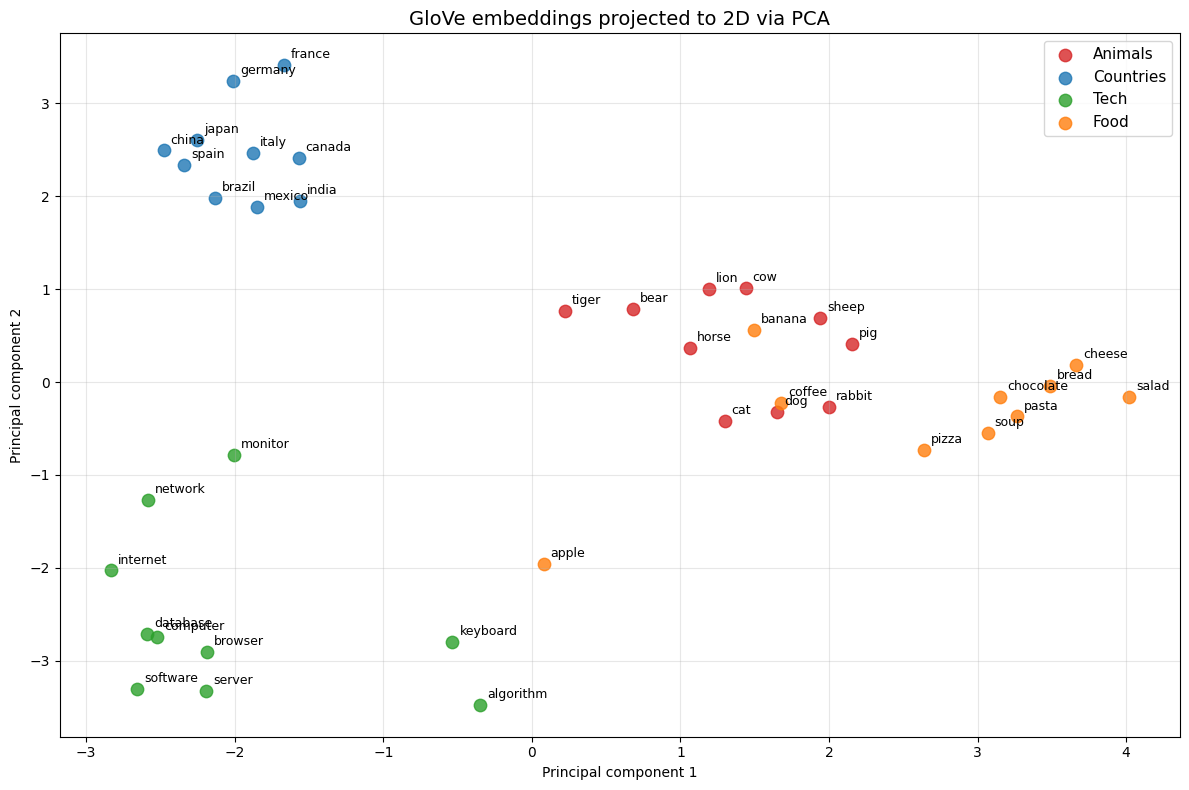

Clusters are visibly separated — and nobody told the model what
a 'country' or 'animal' is. Training figured it out from co-occurrence alone.


In [12]:
words_by_category = {
    "Animals": ["dog", "cat", "horse", "cow", "pig", "sheep", "rabbit", "tiger", "lion", "bear"],
    "Countries": [
        "france",
        "germany",
        "italy",
        "spain",
        "japan",
        "china",
        "india",
        "brazil",
        "canada",
        "mexico",
    ],
    "Tech": [
        "computer",
        "software",
        "internet",
        "database",
        "algorithm",
        "network",
        "server",
        "browser",
        "keyboard",
        "monitor",
    ],
    "Food": [
        "bread",
        "cheese",
        "apple",
        "banana",
        "pasta",
        "pizza",
        "chocolate",
        "coffee",
        "salad",
        "soup",
    ],
}
colors = {"Animals": "#d62728", "Countries": "#1f77b4", "Tech": "#2ca02c", "Food": "#ff7f0e"}

# Collect vectors
words, vectors, categories = [], [], []
for category, cat_words in words_by_category.items():
    for w in cat_words:
        if w in glove:
            words.append(w)
            vectors.append(glove[w])
            categories.append(category)
vectors = np.array(vectors)

# PCA via SVD — no sklearn required
centered = vectors - vectors.mean(axis=0)
_, _, vt = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vt[:2].T

# Scatter, colored by category
fig, ax = plt.subplots(figsize=(12, 8))
for category, color in colors.items():
    mask = [c == category for c in categories]
    points = coords[mask]
    ax.scatter(points[:, 0], points[:, 1], c=color, label=category, s=80, alpha=0.8)
for word, (x, y) in zip(words, coords, strict=True):
    ax.annotate(word, (x, y), fontsize=9, xytext=(5, 5), textcoords="offset points")
ax.set_title("GloVe embeddings projected to 2D via PCA", fontsize=14)
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.legend(loc="best", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Clusters are visibly separated — and nobody told the model what")
print("a 'country' or 'animal' is. Training figured it out from co-occurrence alone.")

## 📍 Position Matters (And Embeddings Alone Don't Carry It)

"Dog bites man" and "man bites dog" use the exact same tokens. If all we give the model is the set of token vectors, it cannot tell them apart — attention is **order-independent**.

Watch.

In [13]:
# Build a tiny vocab by hand for this demo
demo_vocab = {"dog": 0, "bites": 1, "man": 2}
demo_emb = TokenEmbedding(vocab_size=3, d_model=8, seed=SEED)

sentence_a = [demo_vocab["dog"], demo_vocab["bites"], demo_vocab["man"]]
sentence_b = [demo_vocab["man"], demo_vocab["bites"], demo_vocab["dog"]]

vecs_a = demo_emb.lookup(sentence_a)
vecs_b = demo_emb.lookup(sentence_b)

# Two different sentences. But the *set* of vectors is identical —
# just reordered. Attention (coming in Part 3) is permutation-invariant,
# so it cannot distinguish them from token embeddings alone.
print("Set of vectors for 'dog bites man' == set for 'man bites dog'?")
print(" ", np.allclose(sorted(vecs_a.flatten()), sorted(vecs_b.flatten())))
print()
print("We need a way to tell the model *where* each token is.")
print("That's the job of positional encodings.")

Set of vectors for 'dog bites man' == set for 'man bites dog'?
  True

We need a way to tell the model *where* each token is.
That's the job of positional encodings.


## 🌊 Sinusoidal Positional Encoding

The original Transformer paper used a clever trick: **no learned parameters at all**. Each position gets a fixed vector made of interleaved sines and cosines:

$$
\text{PE}(\text{pos}, 2i) = \sin\!\left(\frac{\text{pos}}{10000^{2i/d_{\text{model}}}}\right)
\qquad
\text{PE}(\text{pos}, 2i+1) = \cos\!\left(\frac{\text{pos}}{10000^{2i/d_{\text{model}}}}\right)
$$

Different dimensions oscillate at different wavelengths. Low dims wiggle fast (sensitive to adjacent positions), high dims wiggle slow (sensitive to large-scale position). Together they form a multi-scale position "clock".

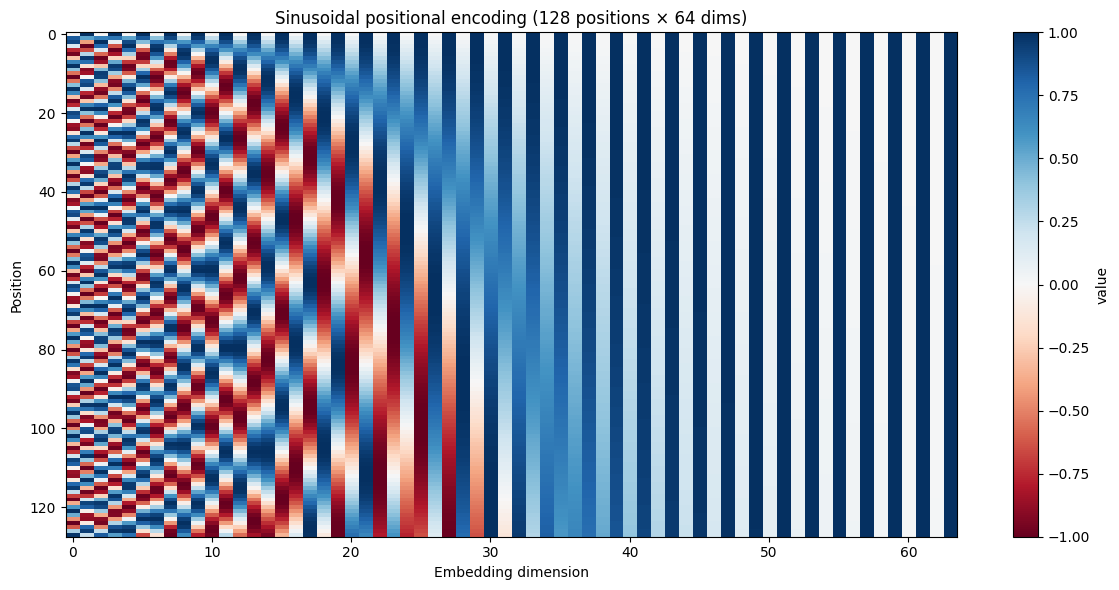

In [14]:
# Build a sinusoidal encoder and look at the matrix as a heatmap
sinu = SinusoidalPositionalEncoding(max_len=128, d_model=64)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(sinu.weight, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Sinusoidal positional encoding (128 positions × 64 dims)")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Position")
plt.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()

# Low dims (left) oscillate fast. High dims (right) oscillate slowly.
# Every row (= every position) has a unique fingerprint.

### 🎯 The Useful Property

Why sines and cosines? The dot product between two position vectors **decays smoothly with distance**. That gives attention a built-in notion of "nearness" without having to learn it.

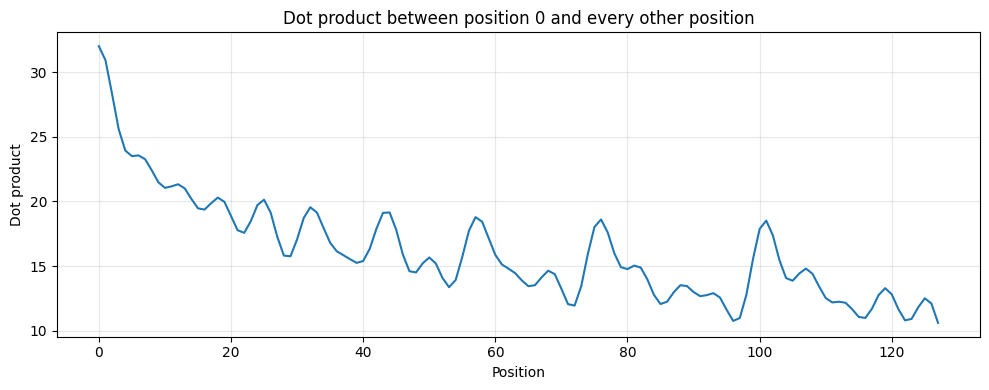

Position 0 vs position 1:   30.92  (near → high)
Position 0 vs position 50:  15.67  (middle)
Position 0 vs position 127: 10.62  (far → lower)


In [15]:
# Compare position 0 against every other position via dot product
dots = sinu.weight @ sinu.weight[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dots)
ax.set_title("Dot product between position 0 and every other position")
ax.set_xlabel("Position")
ax.set_ylabel("Dot product")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Position 0 vs position 1:   {dots[1]:.2f}  (near → high)")
print(f"Position 0 vs position 50:  {dots[50]:.2f}  (middle)")
print(f"Position 0 vs position 127: {dots[127]:.2f}  (far → lower)")

## 🎓 Learned Positional Embeddings (GPT-2 Style)

The alternative: just use another lookup table, one row per position, **learned during training**. Same machinery as `TokenEmbedding`, different semantics.

### Tradeoff

| | Sinusoidal | Learned |
|---|---|---|
| **Parameters** | 0 | `max_len × d_model` |
| **Extrapolates past max_len?** | Yes | No (unseen positions are random) |
| **Flexibility** | Fixed wavelengths | Can shape itself to the task |
| **Used by** | Original Transformer (Vaswani 2017) | GPT-2, most modern LLMs |

For tiny educational models either works. GPT-2 picked learned, so modern practice has followed; sinusoidal remains useful when you need to handle sequences longer than you trained on.

In [16]:
learned = LearnedPositionalEmbedding(max_len=128, d_model=64, seed=SEED)

print("Learned positional — same shape as sinusoidal, different content:")
print(f"  weight shape: {learned.weight.shape}")
print(f"  init std:     {learned.weight.std():.3f}  (random ~0.02, same as TokenEmbedding)")
print()
print("At init the vectors are random noise. The positions are not yet meaningful —")
print("they become meaningful only after training pushes useful position signals into them.")
print()
print("Critically: both encoders expose the same .encode(seq_len) method, so they're")
print("drop-in interchangeable in build_input_embedding:")

sinu_out = sinu.encode(5)
learned_out = learned.encode(5)
print(f"  sinu.encode(5).shape    = {sinu_out.shape}")
print(f"  learned.encode(5).shape = {learned_out.shape}")

Learned positional — same shape as sinusoidal, different content:
  weight shape: (128, 64)
  init std:     0.020  (random ~0.02, same as TokenEmbedding)

At init the vectors are random noise. The positions are not yet meaningful —
they become meaningful only after training pushes useful position signals into them.

Critically: both encoders expose the same .encode(seq_len) method, so they're
drop-in interchangeable in build_input_embedding:
  sinu.encode(5).shape    = (5, 64)
  learned.encode(5).shape = (5, 64)


## ➕ Putting It Together: `token_emb + pos_emb`

The actual input that attention receives in Part 3 is the **elementwise sum** of a token embedding and a positional encoding. Each row then carries both *what* the token is and *where* it sits.

`build_input_embedding` wraps this up so swapping sinusoidal ↔ learned is a one-line change.

In [17]:
token_emb = TokenEmbedding(vocab_size=1000, d_model=64, seed=SEED)
pos_enc = SinusoidalPositionalEncoding(max_len=128, d_model=64)

# Single sequence
seq = [5, 2, 9, 17, 42]
x = build_input_embedding(seq, token_emb, pos_enc)
print(f"Single sequence: {len(seq)} tokens → shape {x.shape}  # (seq_len, d_model)")

# Batched: two sequences of length 5. Positions broadcast across the batch.
batch = [[5, 2, 9, 17, 42], [1, 8, 3, 22, 99]]
x_batch = build_input_embedding(batch, token_emb, pos_enc)
print(
    f"Batch of 2:      {len(batch)} × {len(batch[0])} tokens → shape {x_batch.shape}  # (batch, seq, d_model)"
)
print()
print("Same tokens at the same positions get identical input vectors.")
print("Different tokens or different positions change the vector. That's the entire point.")

Single sequence: 5 tokens → shape (5, 64)  # (seq_len, d_model)
Batch of 2:      2 × 5 tokens → shape (2, 5, 64)  # (batch, seq, d_model)

Same tokens at the same positions get identical input vectors.
Different tokens or different positions change the vector. That's the entire point.


## 🧩 Try It Yourself

Three quick experiments. Change the inputs and see what changes.

In [18]:
# Experiment 1: your own analogies.
# Type words that exist in GloVe (lowercase, common English). See what comes back.

your_analogies = [
    (["doctor", "woman"], ["man"], "doctor - man + woman = ?"),
    (["coffee", "tea"], ["caffeine"], "coffee - caffeine + tea = ?"),
    # add your own!
]

for positive, negative, description in your_analogies:
    result = glove.most_similar(positive=positive, negative=negative, topn=3)
    print(description)
    for word, score in result:
        print(f"    {word:<15} {score:.3f}")
    print()

doctor - man + woman = ?
    nurse           0.840
    child           0.766
    pregnant        0.757

coffee - caffeine + tea = ?
    coconut         0.696
    plantation      0.689
    shop            0.681



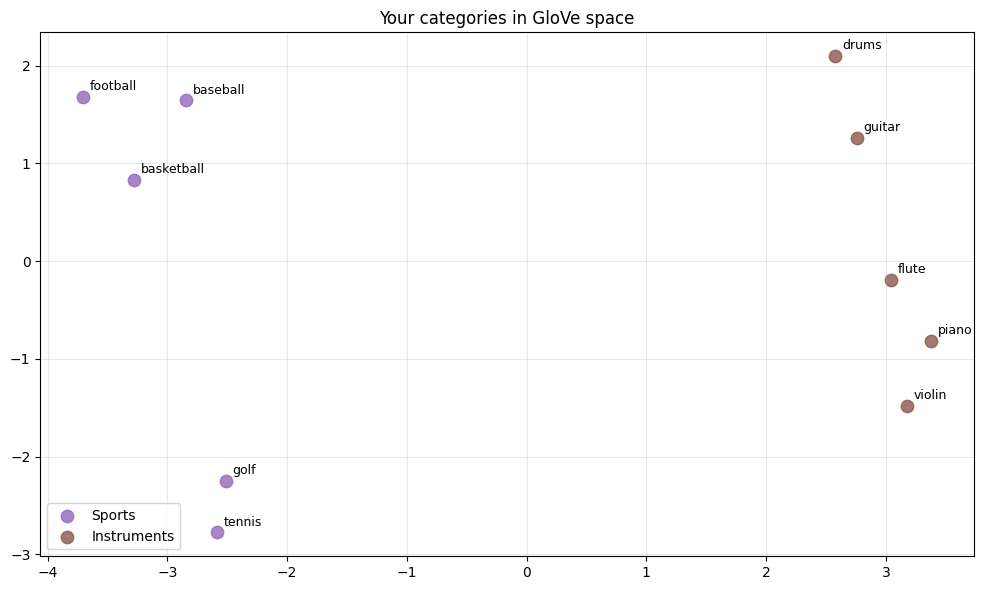

In [19]:
# Experiment 2: pick your own word categories and plot them.
# Try pairs that SHOULD separate (cats vs. cars) and pairs that maybe shouldn't
# (sports vs. activities). Note where PCA's 2D projection is lossy.

my_categories = {
    "Sports": ["football", "basketball", "tennis", "golf", "baseball"],
    "Instruments": ["guitar", "piano", "violin", "drums", "flute"],
}
my_colors = {"Sports": "#9467bd", "Instruments": "#8c564b"}

words, vectors, cats = [], [], []
for cat, cws in my_categories.items():
    for w in cws:
        if w in glove:
            words.append(w)
            vectors.append(glove[w])
            cats.append(cat)
vectors = np.array(vectors)
centered = vectors - vectors.mean(axis=0)
_, _, vt = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vt[:2].T

fig, ax = plt.subplots(figsize=(10, 6))
for cat, color in my_colors.items():
    mask = [c == cat for c in cats]
    points = coords[mask]
    ax.scatter(points[:, 0], points[:, 1], c=color, label=cat, s=80, alpha=0.8)
for w, (x, y) in zip(words, coords, strict=True):
    ax.annotate(w, (x, y), fontsize=9, xytext=(5, 5), textcoords="offset points")
ax.set_title("Your categories in GloVe space")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

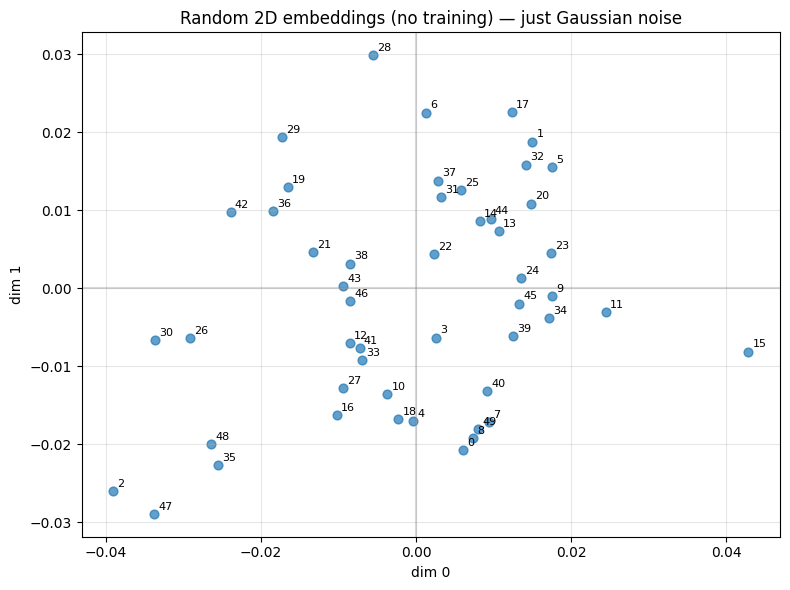

No structure — just noise around the origin.
Training is what turns this into something meaningful.


In [20]:
# Experiment 3: d_model = 2.
# Train a tiny random embedding at d_model=2 so you can plot the raw vectors
# directly. No PCA needed. This is a good way to see how random init looks
# before any training rearranges the points.

small_emb = TokenEmbedding(vocab_size=50, d_model=2, seed=SEED)
pts = small_emb.weight

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pts[:, 0], pts[:, 1], s=40, alpha=0.7)
for i, (x, y) in enumerate(pts):
    ax.annotate(str(i), (x, y), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set_title("Random 2D embeddings (no training) — just Gaussian noise")
ax.set_xlabel("dim 0")
ax.set_ylabel("dim 1")
ax.axhline(0, color="gray", alpha=0.3)
ax.axvline(0, color="gray", alpha=0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("No structure — just noise around the origin.")
print("Training is what turns this into something meaningful.")

## 🎯 Key Takeaways

1. **Embeddings are just a matrix.** One row per token, one column per dimension. Looking up token *N* means picking row *N*. That's the whole mechanism.
2. **Random at init, meaningful after training.** The same lookup produces noise before training and the `king - man + woman = queen` magic after.
3. **`torch.nn.Embedding` is that lookup plus autograd.** If you understand the NumPy version, you understand the PyTorch version.
4. **Position has to be injected separately.** Two options: sinusoidal (deterministic, extrapolates) or learned (flexible, GPT-2 style).
5. **The input transformers actually see is `token_emb + pos_emb`** — the elementwise sum carries both identity and order.

## 🔮 What's Next: Part 3 — Attention

Each token in your sequence is now a rich vector carrying both *what* it is and *where* it sits. But the model still doesn't know that "it" refers to "the cat" in "the cat sat on the mat because **it** was tired."

That's what **attention** does. It's the mechanism that lets every token's vector look around and pull information from the other tokens — the "context window" in action.

See you in Part 3. 🚀

---

## 🔗 Additional Resources

- **[Part 2 Blog Post](https://asyncthinking.com)** — the written companion to this notebook
- **[Full MiniGPT Repo](https://github.com/naresh-sharma/mini-gpt)** — code, tests, and upcoming parts
- **[Example scripts](https://github.com/naresh-sharma/mini-gpt/tree/main/examples)** — `embedding_demo.py` and `visualize_embeddings.py` for standalone runs
- **[GloVe paper (Pennington et al., 2014)](https://nlp.stanford.edu/pubs/glove.pdf)** — the training method behind the pretrained vectors you used
- **[Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)** — introduces sinusoidal positional encoding

**Happy embedding!** 🎉
